In [24]:
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

c:\Users\jmgra\anaconda3\envs\ModelingLab\Lib\site-packages\scipy\integrate\_ivp\ivp.py:621: UserWarning: The following arguments have no effect for a chosen solver: `teval`.
  solver = method(fun, t0, y0, tf, vectorized=vectorized, **options)


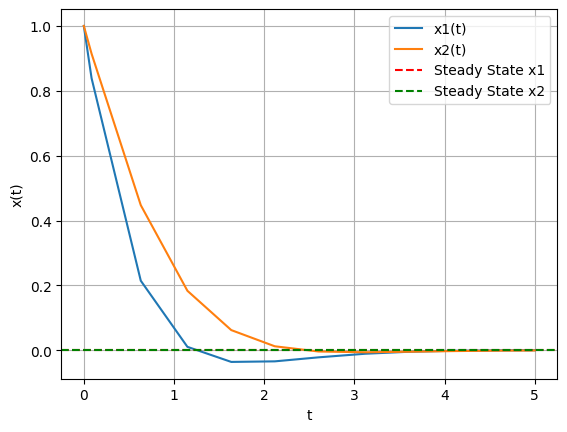

ODE Solution at t=5:
    Time     x1(t)   x2(t)
11   5.0  0.000091 -0.0005

Steady State Solution:
  Variable  Steady State Value  Final value(ODE)
0       x1                 0.0          0.000091
1       x2                 0.0         -0.000500


In [25]:
#Exerice 1

#initial conditions
x0 = np.array([1,1])
tspan = [0,5]

#solve the system of ODEs
def f(t,x):
    M = np.array([[-1,-1],[1,-2]])
    dxdt = np.dot(M,x)
    return dxdt

sol = solve_ivp(f, tspan, x0, method="RK45", teval=np.linspace(0, 5, 100))

#Steady state solution
def steadystate(x):
    return f(0, x)

steadystate_solution = fsolve(steadystate, x0)

#plot the results
plt.figure()
plt.plot(sol.t, sol.y[0], label="x1(t)")
plt.plot(sol.t, sol.y[1], label="x2(t)")
plt.axhline(steadystate_solution[0], color='r', linestyle='--', label="Steady State x1")
plt.axhline(steadystate_solution[1], color='g', linestyle='--', label="Steady State x2")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.show()

#display of results
results = pd.DataFrame({
    "Time": sol.t,
    "x1(t)": sol.y[0],
    "x2(t)": sol.y[1]
})
results

steady_state_df = pd.DataFrame({
    "Variable": ["x1", "x2"],
    "Steady State Value": steadystate_solution,
    "Final value(ODE)": [sol.y[0][-1], sol.y[1][-1]]
})
steady_state_df

print("ODE Solution at t=5:")
print(results.tail(1)) 
print("\nSteady State Solution:")
print(steady_state_df)

In [26]:
plt.close("all")

In [ ]:
#Exerice 2

#Non stiff method
